# Instacart — Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = "../data/combined_instacart_data.csv"

## 1. Load Data

In [2]:
df = pd.read_csv(DATA_PATH, dtype={
    'user_id': 'int32', 'order_id': 'int32', 'product_id': 'int32',
    'aisle_id': 'int16', 'department_id': 'int8', 'order_number': 'int16',
    'order_dow': 'int8', 'order_hour_of_day': 'int8',
    'add_to_cart_order': 'int16', 'reordered': 'int8'
})
df['days_since_prior_order'] = df['days_since_prior_order'].astype('float32')
print("Shape:", df.shape)
print("Memory:", round(df.memory_usage(deep=True).sum()/1e6, 1), "MB")
df.head()

Shape: (33819106, 15)
Memory: 3736.8 MB


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry


## 2. Dataset Overview

In [3]:
print("Unique users   :", df['user_id'].nunique())
print("Unique orders  :", df['order_id'].nunique())
print("Unique products:", df['product_id'].nunique())
print("Unique aisles  :", df['aisle_id'].nunique())
print("Unique depts   :", df['department_id'].nunique())
print("Reorder rate   :", round(df['reordered'].mean(), 4))

Unique users   : 206209
Unique orders  : 3346083
Unique products: 49685
Unique aisles  : 134
Unique depts   : 21
Reorder rate   : 0.5901


## 3. Missing Values

In [4]:
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
pd.DataFrame({'Count': miss, 'Pct': miss_pct})[miss > 0]

,Count,Pct
days_since_prior_order,2078068,6.14


## 4. Orders by Hour of Day

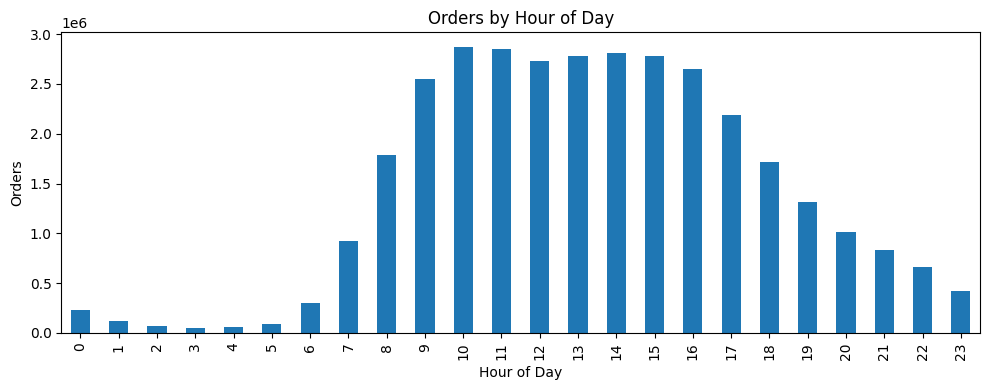

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
df['order_hour_of_day'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Orders')
ax.set_title('Orders by Hour of Day')
plt.tight_layout()
plt.show()

## 5. Orders by Day of Week

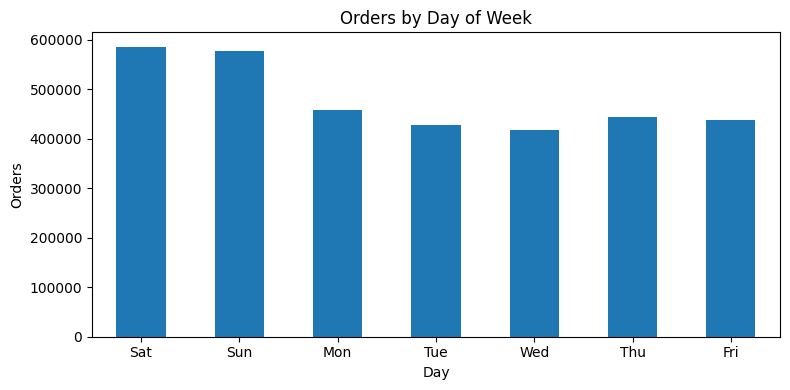

In [6]:
dow_map = {0:'Sat',1:'Sun',2:'Mon',3:'Tue',4:'Wed',5:'Thu',6:'Fri'}
dow = df.groupby('order_dow')['order_id'].nunique()
dow.index = dow.index.map(dow_map)
fig, ax = plt.subplots(figsize=(8, 4))
dow.plot(kind='bar', ax=ax)
ax.set_xlabel('Day')
ax.set_ylabel('Orders')
ax.set_title('Orders by Day of Week')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Days Since Prior Order

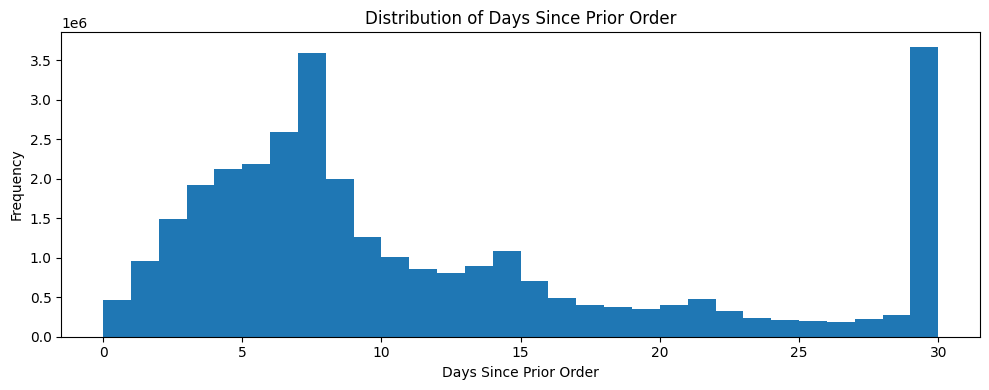

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
df['days_since_prior_order'].dropna().plot(kind='hist', bins=30, ax=ax)
ax.set_xlabel('Days Since Prior Order')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Days Since Prior Order')
plt.tight_layout()
plt.show()

## 7. Top 20 Products

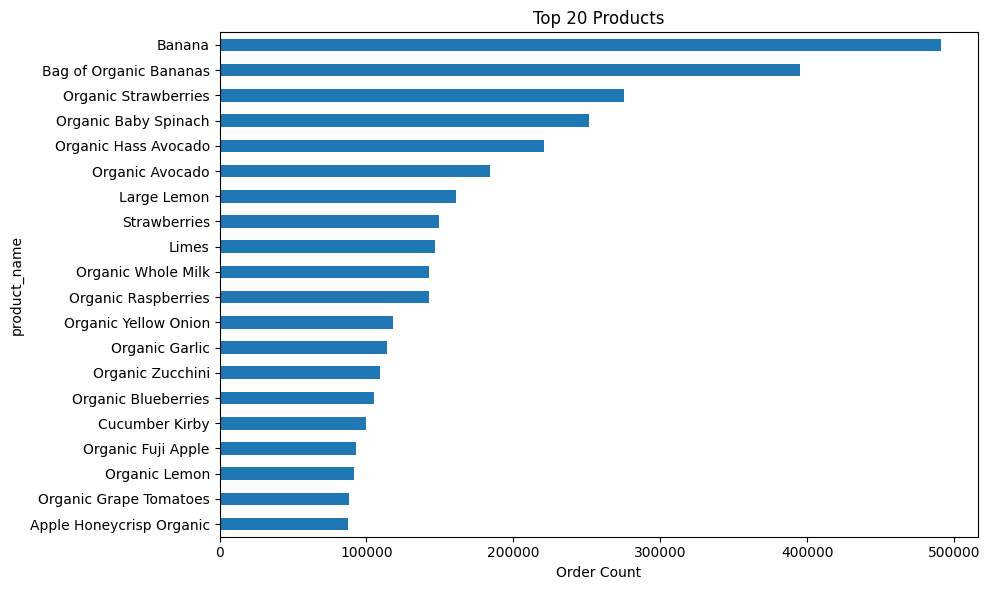

In [8]:
top_p = df['product_name'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top_p.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Order Count')
ax.set_title('Top 20 Products')
plt.tight_layout()
plt.show()

## 8. Top 20 Aisles

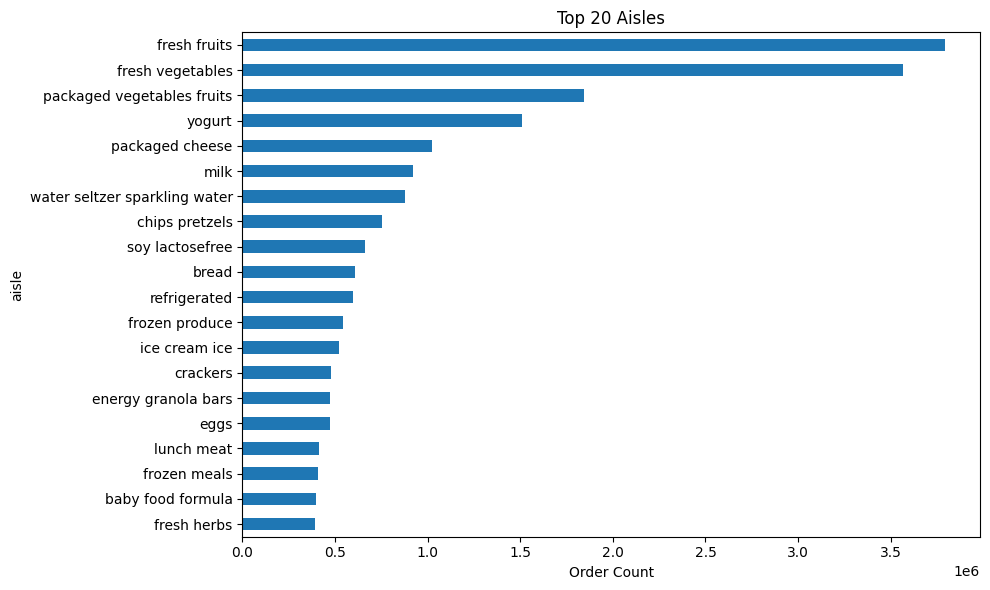

In [9]:
top_a = df['aisle'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top_a.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Order Count')
ax.set_title('Top 20 Aisles')
plt.tight_layout()
plt.show()

## 9. Orders by Department

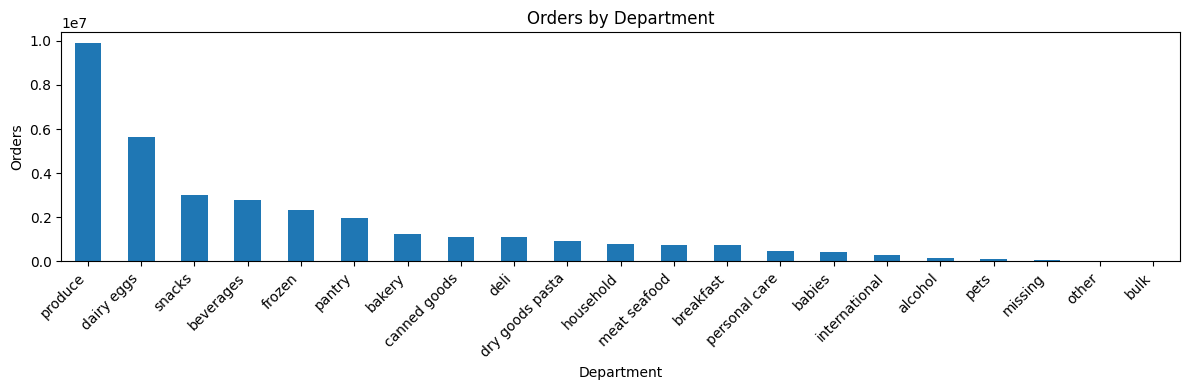

In [10]:
dept = df.groupby('department')['order_id'].count().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 4))
dept.plot(kind='bar', ax=ax)
ax.set_xlabel('Department')
ax.set_ylabel('Orders')
ax.set_title('Orders by Department')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Reorder Rate by Department

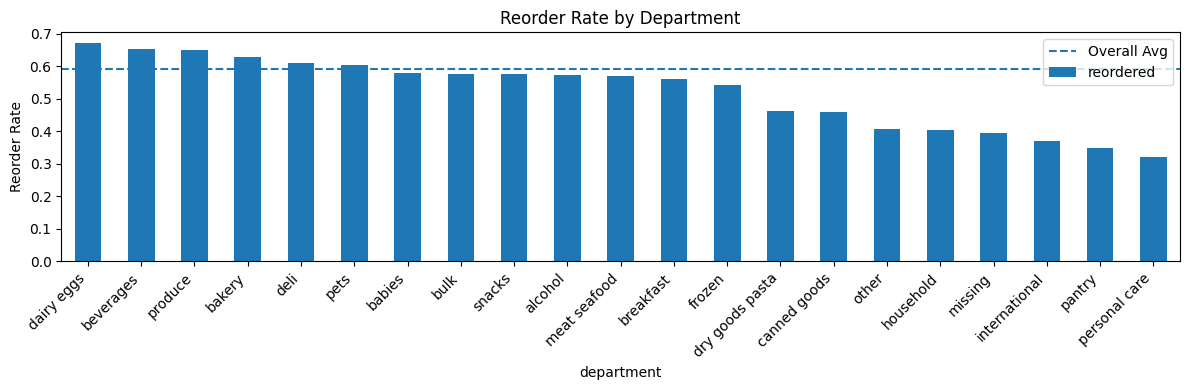

In [11]:
rr_dept = df.groupby('department')['reordered'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 4))
rr_dept.plot(kind='bar', ax=ax)
ax.axhline(df['reordered'].mean(), linestyle='--', label='Overall Avg')
ax.set_ylabel('Reorder Rate')
ax.set_title('Reorder Rate by Department')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 11. Reorder Rate by Hour

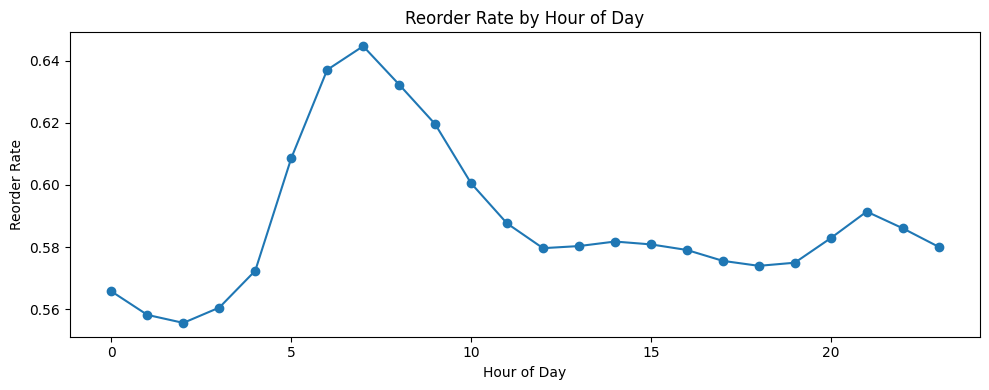

In [12]:
rr_hour = df.groupby('order_hour_of_day')['reordered'].mean()
fig, ax = plt.subplots(figsize=(10, 4))
rr_hour.plot(kind='line', marker='o', ax=ax)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Reorder Rate')
ax.set_title('Reorder Rate by Hour of Day')
plt.tight_layout()
plt.show()

## 12. Basket Size Distribution

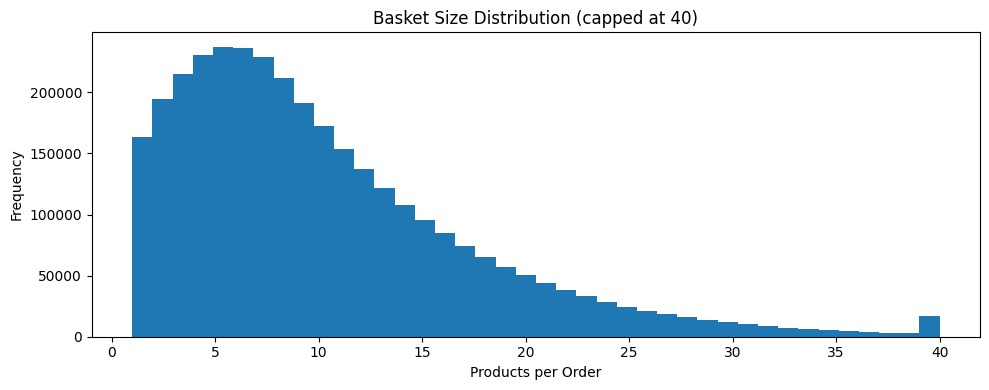

Mean: 10.11  Median: 8.0


In [13]:
basket = df.groupby('order_id')['product_id'].count()
fig, ax = plt.subplots(figsize=(10, 4))
basket.clip(upper=40).plot(kind='hist', bins=40, ax=ax)
ax.set_xlabel('Products per Order')
ax.set_ylabel('Frequency')
ax.set_title('Basket Size Distribution (capped at 40)')
plt.tight_layout()
plt.show()
print("Mean:", round(basket.mean(), 2), " Median:", basket.median())

## 13. Orders per User

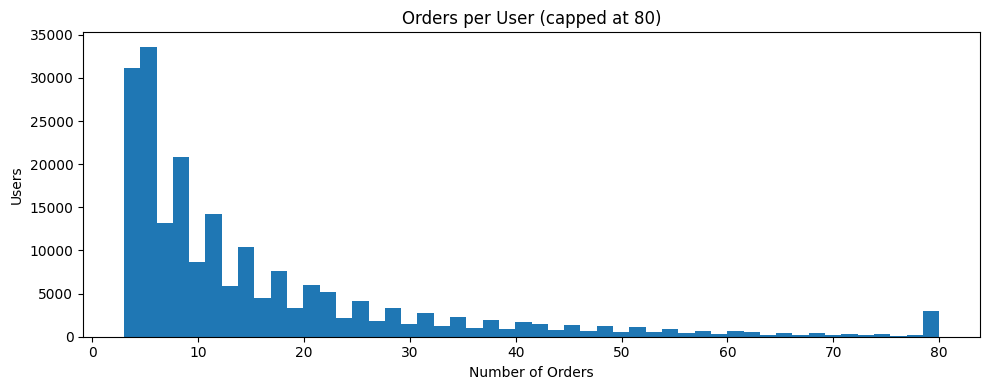

Mean: 16.23  Median: 10.0


In [14]:
opu = df.groupby('user_id')['order_id'].nunique()
fig, ax = plt.subplots(figsize=(10, 4))
opu.clip(upper=80).plot(kind='hist', bins=50, ax=ax)
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Users')
ax.set_title('Orders per User (capped at 80)')
plt.tight_layout()
plt.show()
print("Mean:", round(opu.mean(), 2), " Median:", opu.median())